You can just click **Runtime → Run all** to try the demo.

# Module 5: Large Language Models — How Models Use Context, and What Their Training Data Contributes

This module introduces transformer-based language models and shows how they advance from older methods by capturing richer context, learning more expressive patterns. Additionally, we will briefly touch upon how influence of training data can be technically evaluated.

## Demo Sections (With Conceptual Anchoring)

In [1]:
#@title system-setup
# install required packages

# load required modules

import seaborn as sns
import sklearn
import transformers
import torch

import pandas as pd
import os
from collections import defaultdict
import pickle

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity


from sklearn.linear_model import LogisticRegression


from sentence_transformers import SentenceTransformer, util

from textwrap import fill

import warnings
warnings.filterwarnings('ignore')

from transformers import logging
logging.set_verbosity_error()

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Section 1: BERT for Encoding — Understanding Words in Context
**Goal:** Explain how BERT encodes words by considering their context, overcoming limitations of Bag of Words.

**Key points:**
- Briefly introduce the Transformer architecture as the backbone of BERT (self-attention mechanism enables context-aware encoding).
Show simple examples of the same word in different sentences with different meanings.
- Visualize self-attention maps (static, eye-friendly heatmaps) to illustrate how BERT “attends” to different words when encoding a target word.
- Revisit Bag of Words limitations (word order, negation) to motivate contextual embeddings.

# Part 1 - Context Matters: Word Frequency vs BERT
In Module 1, we used **Bag of Words (BoW)** to "encode" words by counting their frequencies. This simple method captures some information but ignores word order and context.

In this demo, we compare **BoW** and **BERT**, a more advanced model that understands word order and context, by checking how they perceive similarity between sentence pairs. In this particular case, we use a more sophisticated model called **SBERT (sentence BERT)** in order to avoid some pitfalls in shorter sentences.

Let's see how they handle these sentences:
- "dog bites man" vs "cat bites man"
- "dog bites man" vs "man bites dog"

In [2]:
#@title BoW vs SBERT: frequency vs context (a bit slow) {display-mode: "form"}

# Sentences to compare
sentences = [
    ("A dog bites the man.", "A cat bites the man."),
    ("A dog bites the man.", "The man bites a dog.")
]

# Bag of Words similarity
def bow_similarity(sent1, sent2, corpus):
    vectorizer = CountVectorizer().fit(corpus)
    vecs = vectorizer.transform([sent1, sent2])
    sim = cosine_similarity(vecs[0], vecs[1])[0][0]
    return sim

# Sentence-BERT similarity
def sbert_similarity(sent1, sent2, model):
    embeddings = model.encode([sent1, sent2], convert_to_tensor=True)
    sim = util.pytorch_cos_sim(embeddings[0], embeddings[1]).item()
    return sim

# Prepare corpus for BoW (all sentences involved)
corpus = list(set([s for pair in sentences for s in pair]))

# Load Sentence-BERT model
sbert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Run comparisons
for sent1, sent2 in sentences:
    bow_sim = bow_similarity(sent1, sent2, corpus)
    bert_sim = sbert_similarity(sent1, sent2, sbert_model)

    print(f'Input 1: "{sent1}"')
    print(f'Input 2: "{sent2}"')
    #print(f'BoW similarity: {bow_sim:.2f}')
    if bow_sim > 0.98:
        print("BoW output: They are the same sentence (BoW ignores word order).")
    else:
        print("BoW output: They are different sentences (different words).")

    #print(f'BERT similarity: {bert_sim:.2f}')
    if bert_sim > 0.98:
        print("BERT output: They are the same sentence.")
    else:
        print("BERT output: They are different sentences (BERT understands context and order).")
    print("\n" + "-"*50 + "\n")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Input 1: "A dog bites the man."
Input 2: "A cat bites the man."
BoW output: They are different sentences (different words).
BERT output: They are different sentences (BERT understands context and order).

--------------------------------------------------

Input 1: "A dog bites the man."
Input 2: "The man bites a dog."
BoW output: They are the same sentence (BoW ignores word order).
BERT output: They are different sentences (BERT understands context and order).

--------------------------------------------------



### Sentiment Analysis
In addition to better understanding the context, BERT is also widely used to analyze the sentiment in the sentences. Here, we will load some pre-run results with Bag of Words and SBERT, in addition to logistic regression, to demonstrate how machine categorize the "emotions" in the sentences to be positive or negative

### Data set: SST-2

Stanford Sentiment Treebank 2(SST-2) is distributed via the [The General Language Understanding Evaluation (GLUE) benchmark](https://gluebenchmark.com/) and originates from: `Socher et al. (2013), Recursive Deep Models for Semantic Compositionality Over a Sentiment Treebank`, but it is openly available for non-commercial academic purposes.

The GLUE benchmark is a collection of language understanding tasks (e.g., sentiment classification, sentence similarity, entailment) created to evaluate how well models understand natural language. and SST-2 is one of them, focused on binary sentiment classification. SST-2 is derived from movie reviews on Rotten Tomatoes, originally scraped and parsed into phrases.

For both necessity and legal consideration, we only use a small subset from the SST-2 data set in this demo. This subset contains 1000 examples (`<0.04%` of the whole set), publicly available via Hugging Face for non-commercial educational use. This file is for illustrative purposes only.

In [5]:
#@title Load dataset {display-mode: "form"}

# load the SST-2 subset from a pre-generated csv file
base_url = 'https://raw.githubusercontent.com/WeihaoGe1009/ai-history-for-ip-scholars/main/05_llms/'
#base_url = '/content/drive/MyDrive/05_llms_demo'
data_path = os.path.join(base_url, 'data','sst2_long_subset.csv')
df = pd.read_csv(data_path)

# Split into train and test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [6]:
#@title Evaluate correctness of BoW and SBERT {display-mode: "form"}
RUN_SLOW = False # if you want to try the code, change "False" to "True" here

def get_predictions_bow(train_df, test_df):
    vectorizer = CountVectorizer()
    X_train = vectorizer.fit_transform(train_df['sentence'])
    X_test = vectorizer.transform(test_df['sentence'])

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, train_df['label'])
    preds = clf.predict(X_test)
    return preds

def get_predictions_sbert(train_df, test_df):
    model = SentenceTransformer('all-MiniLM-L6-v2')
    emb_train = model.encode(train_df['sentence'].tolist())
    emb_test = model.encode(test_df['sentence'].tolist())

    clf = LogisticRegression(max_iter=1000)
    clf.fit(emb_train, train_df['label'])
    preds = clf.predict(emb_test)
    return preds

def compare_predictions(test_df, y_pred_bow, y_pred_sbert):
    results = defaultdict(list)
    for i, (true, bow, sbert) in enumerate(zip(test_df["label"], y_pred_bow, y_pred_sbert)):
        sent = test_df["sentence"].iloc[i]
        if true == bow == sbert:
            results["both_correct"].append(sent)
        elif bow == true and sbert != true:
            results["only_bow_correct"].append(sent)
        elif sbert == true and bow != true:
            results["only_sbert_correct"].append(sent)
        else:
            results["both_wrong"].append(sent)
    return results


def save_files(path, preds):
    with open(path, "wb") as f:
        pickle.dump(preds, f)

def load_files(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def label_to_str(label):
    return "positive" if int(label) == 1 else "negative"

def pretty_print_result(sentence, lookup_dict):
    true_label, pred_bow, pred_sbert = lookup_dict[sentence]
    print(f"Sentence: {fill(sentence, width=80)}")
    print(f"True Label   : {label_to_str(true_label)}")
    print(f"BoW Prediction: {label_to_str(pred_bow)}")
    print(f"SBERT Prediction: {label_to_str(pred_sbert)}")
    print("-" * 50)


dict_path = "sbert_vs_bow_comparison.pkl"
lookup_path = "prediction_lookup.pkl"

if RUN_SLOW:
  y_pred_bow = get_predictions_bow(train_df, test_df)
  y_pred_sbert = get_predictions_sbert(train_df, test_df)
  print('saving the Venn table')
  sent_dict = compare_predictions(test_df, y_pred_bow, y_pred_sbert)
  save_files(dict_path, sent_dict)
  print('Venn table saved.')

  # Build a lookup dict from sentence to (true_label, bow_pred, sbert_pred)
  lookup = {
    row['sentence']: (row['label'], y_pred_bow[i], y_pred_sbert[i])
    for i, row in test_df.iterrows()
  }
  print("saving lookup dictionary.")
  save_files(lookup_path, lookup)
  print('completed saving')
else:
  result_path = os.path.join(dict_path)
  sent_dict = load_files(result_path)
  lookup_pred = os.path.join(lookup_path)
  lookup = load_files(lookup_pred)


print(f"Both correct: {len(sent_dict['both_correct'])}")
print(f"Both wrong: {len(sent_dict['both_wrong'])}")
print(f"Uniquely correctly predicted by BoW: {len(sent_dict['only_bow_correct'])}")
print(f"Uniquely correctly predicted by SBERT: {len(sent_dict['only_sbert_correct'])}")

print('\n')
print("Now let's look at some example sentences:\n")

for kk in sent_dict.keys():
  for ii in range(2):
    sentence = sent_dict[kk][ii]
    pretty_print_result(sentence, lookup)
  print('\n')


FileNotFoundError: [Errno 2] No such file or directory: 'https://raw.githubusercontent.com/WeihaoGe1009/ai-history-for-ip-scholars/main/05_llms/data/sbert_vs_bow_comparison.pkl'

### What we learnt from these two demos?
* First, SBERT demonstrated the ability to recognize meaning differences caused by word order, while BoW failed due to its disregard for sequence.
* Second, in sentiment classification, both methods correctly identified most examples, but SBERT achieved slightly better accuracy.

This is because BoW relies only on word frequency, while SBERT leverages context to make more nuanced judgments.

Now let's look under-the-hood about how BERT models utilize context. There are two important concepts: **attention mechanism** and **transformer**. The Attention mechanism allows transformers to give different weights to different parts of the sentence. We'll explore how this makes contextual understanding possible.


## Part 2 Predicting a Masked Word
To begin exploring what happens inside the model, we start with a simple task: masked word prediction. By asking the model to guess a missing word in a sentence, we can observe how it "considers" context and assigns weight to different parts of the sentence. This gives us an entry point to understand the internal mechanism of **attention**.

In [ ]:
#@title Load pre-trained model and tokenizer {display-mode: "form"}
from transformers import BertTokenizer, BertForMaskedLM
import torch

# Load pre-trained model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForMaskedLM.from_pretrained('bert-base-uncased')
model.eval()

def predict_masked_word(sentence):
    inputs = tokenizer(sentence, return_tensors='pt')
    mask_index = torch.where(inputs['input_ids'] == tokenizer.mask_token_id)[1]

    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits

    predicted_token_id = logits[0, mask_index, :].argmax(dim=-1).item()
    predicted_word = tokenizer.decode([predicted_token_id])

    completed = sentence.replace(tokenizer.mask_token, predicted_word)

    return predicted_word, completed


In [ ]:
#@title Predicting Masked Words {display-mode: "form"}
sentences = [
    "[MASK] was very late to the meeting, but nobody seemed surprised.",
    "The lawyer [MASK] the documents carefully before signing.",
    "The room was filled with laughter and the atmosphere felt [MASK].",
    "The movie was [MASK], but I liked the soundtrack."
]

for s in sentences:
    word, full = predict_masked_word(s)
    print(f"Masked sentence: {s}")
    print(f"Predicted word: {word}")
    print(f"Completed: {full}")
    print('-' * 60)


Masked sentence: [MASK] was very late to the meeting, but nobody seemed surprised.
Predicted word: it
Completed: it was very late to the meeting, but nobody seemed surprised.
------------------------------------------------------------
Masked sentence: The lawyer [MASK] the documents carefully before signing.
Predicted word: examined
Completed: The lawyer examined the documents carefully before signing.
------------------------------------------------------------
Masked sentence: The room was filled with laughter and the atmosphere felt [MASK].
Predicted word: good
Completed: The room was filled with laughter and the atmosphere felt good.
------------------------------------------------------------
Masked sentence: The movie was [MASK], but I liked the soundtrack.
Predicted word: short
Completed: The movie was short, but I liked the soundtrack.
------------------------------------------------------------



Masked sentence: [MASK] was very late to the meeting, but nobody seemed surprised.


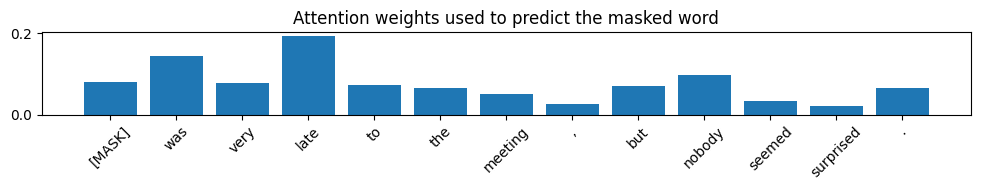


Masked sentence: The lawyer [MASK] the documents carefully before signing.


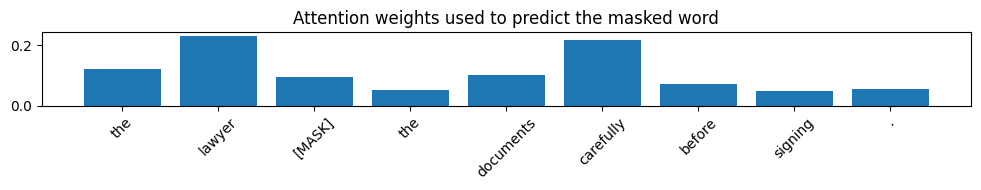


Masked sentence: The room was filled with laughter and the atmosphere felt [MASK].


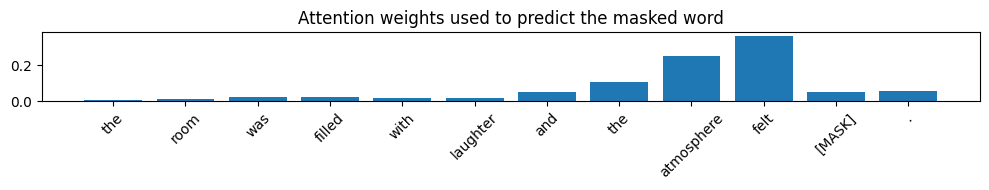


Masked sentence: The movie was [MASK], but I liked the soundtrack.


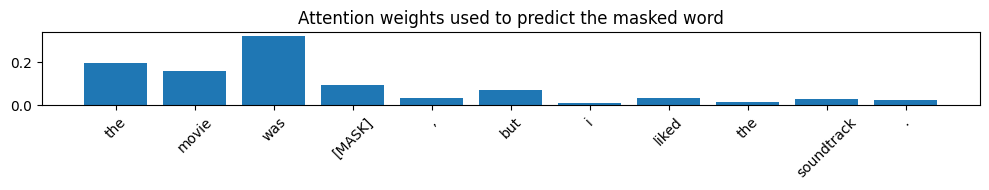

In [ ]:
#@title Under the Hood - Which words get more attention to predict masked words {display-mode: "form"}
import matplotlib.pyplot as plt
import numpy as np

def visualize_attention_on_mask_clean(sentence, model, tokenizer, layer=6):
    inputs = tokenizer(sentence, return_tensors='pt')
    input_ids = inputs['input_ids']
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    # Find mask token index
    mask_index = (input_ids[0] == tokenizer.mask_token_id).nonzero(as_tuple=True)[0].item()

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    attentions = torch.stack(outputs.attentions)  # [layers, batch, heads, seq_len, seq_len]
    attentions = attentions[:, 0]  # Remove batch dim
    mean_attention = attentions[layer].mean(dim=0)  # [seq_len, seq_len]

    mask_attention = mean_attention[mask_index]  # [seq_len]

    # Filter out special tokens
    display_tokens = []
    display_scores = []
    for i, token in enumerate(tokens):
        if token not in ["[CLS]", "[SEP]"]:
            display_tokens.append(token)
            display_scores.append(mask_attention[i].item())

    # Normalize for better visual consistency
    scores = np.array(display_scores)
    scores = scores / scores.sum()

    # Plot
    plt.figure(figsize=(10, 2))
    plt.bar(range(len(display_tokens)), scores)
    plt.xticks(range(len(display_tokens)), display_tokens, rotation=45)
    plt.title(f"Attention weights used to predict the masked word")
    plt.tight_layout()
    plt.show()

for sentence in sentences:
    print(f"\nMasked sentence: {sentence}")
    visualize_attention_on_mask_clean(sentence, model, tokenizer, layer=6)

In the image above, we extracted a middle layer from the BERT model, which balances between raw linguistic signals and high-level model-specific features. Usually such layers tend to show meaningful contextual interactions, such as syntactic and semantic relations

Each bar shows **how much the model “paid attention to” a word** when trying to guess the missing word.
The higher the bar, the more that word influenced the prediction.
This process of weighing different words is how the model understands meaning in context — a key feature of **the Transformer architecture.**

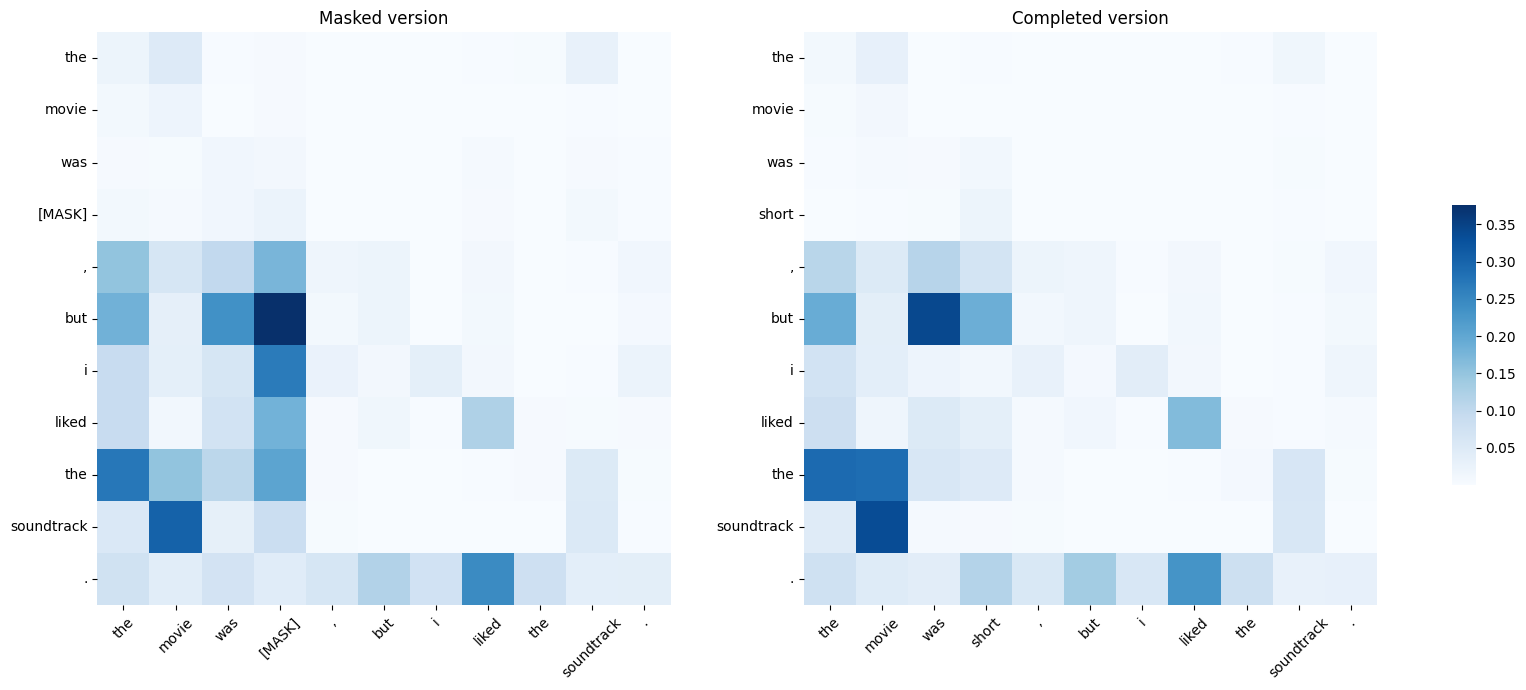

In [ ]:
#@title Now let's look at how each word tries to "understand" other words {display-mode: "form"}
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
model.eval()

# Sentences
sentences = [
    "The movie was [MASK], but I liked the soundtrack.",
    "The movie was short, but I liked the soundtrack."
]

attentions_to_plot = []
token_lists = []

# Process both sentences
for text in sentences:
    inputs = tokenizer(text, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    with torch.no_grad():
        outputs = model(**inputs)
        attention = outputs.attentions[6][0, 0].detach().numpy()  # Layer 6, Head 0

    # Remove [CLS] and [SEP]
    tokens_filtered = tokens[1:-1]
    attention_filtered = attention[1:-1, 1:-1]

    attentions_to_plot.append(attention_filtered)
    token_lists.append(tokens_filtered)

# Get global vmin/vmax for consistent color scale
all_values = np.concatenate([a.flatten() for a in attentions_to_plot])
vmin = all_values.min()
vmax = all_values.max()

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4])  # shared colorbar

for i, ax in enumerate(axes):
    sns.heatmap(attentions_to_plot[i],
                xticklabels=token_lists[i],
                yticklabels=token_lists[i],
                cmap="Blues",
                square=True,
                vmin=vmin,
                vmax=vmax,
                cbar=(i==1),  # only last plot has colorbar
                cbar_ax=(cbar_ax if i==1 else None),
                ax=ax)
    ax.set_title("Masked version" if i==0 else "Completed version")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar
plt.show()


These two heatmaps show how BERT distributes "attention" between words in a sentence. Each row represents a word trying to "understand its context" by looking at other words — the brighter the square, the more attention that word pays to the one on the x-axis. In the first sentence with a missing word (`[MASK]`), the model pays strong attention to “but” when trying to guess the masked adjective. This shows that BERT uses the structure of the sentence (e.g., contrast after “but”) to make educated predictions.

In the second heatmap (the complete sentence), there's no word to guess — but the model still assigns attention to build a richer understanding of each word in context. For example, “movie” attends to “soundtrack”, and “was” attends to “but”, revealing how BERT detects logical or thematic relationships. These patterns come from something called "stacked **attention blocks**" — the core of the **Transformer** architecture — which allow the model to focus dynamically on different parts of the sentence instead of relying only on nearby words.



### Glossaries

**Token**

A token is a small unit of text that the model reads — usually a word or part of a word.
For example, the sentence “I’m happy” might be split into the tokens: `["I", "'", "m", "happy"]`.
The model processes language as a list of these tokens, each with a unique position, rather than as entire sentences.

**Self-Attention**

Self-attention is a technique that lets the model decide which other words (tokens) in a sentence are important for understanding each word.
For example, to understand the word “bank” in “She sat by the bank,” the model pays more attention to “sat” and “by” than it would in “She opened an account at the bank.”
This mechanism helps the model understand context — even when sentences are long or complex.

**Attention Block**

An attention block is a processing step inside a Transformer model.
At each step, the model looks at all the words in the sentence and decides which ones matter most for understanding each word.
This is done by assigning attention weights — numbers that reflect how much one word should influence another.
By repeating this step several times, the model gradually builds a deeper understanding of the sentence. Transformers work by stacking many of these steps together, allowing the model to learn complex patterns and relationships between words at different levels.

**Transformer**

A Transformer is a type of model that processes language by combining many layers of self-attention and small neural networks.
It reads all words at once (not one by one), and uses attention to find important relationships between them.
Because of this, Transformers are especially good at understanding the meaning of words in context — even across long passages.

## Section 3 - Can we Trace Influence? A Toy Attribution Demo.
In the previous sections, we explored how models interpret input by attending to context. But what shaped those interpretations in the first place? At the heart of modern AI models lies a huge collection of training data — millions or even billions of examples.

In this section, we explore how training data influences what the model has learned. Can we trace a prediction back to specific examples it may have seen? We use an oversimplified single variable linear regression model. In large LLMs, more advanced methods and sophisticated approaches are used, but the idea is similar.

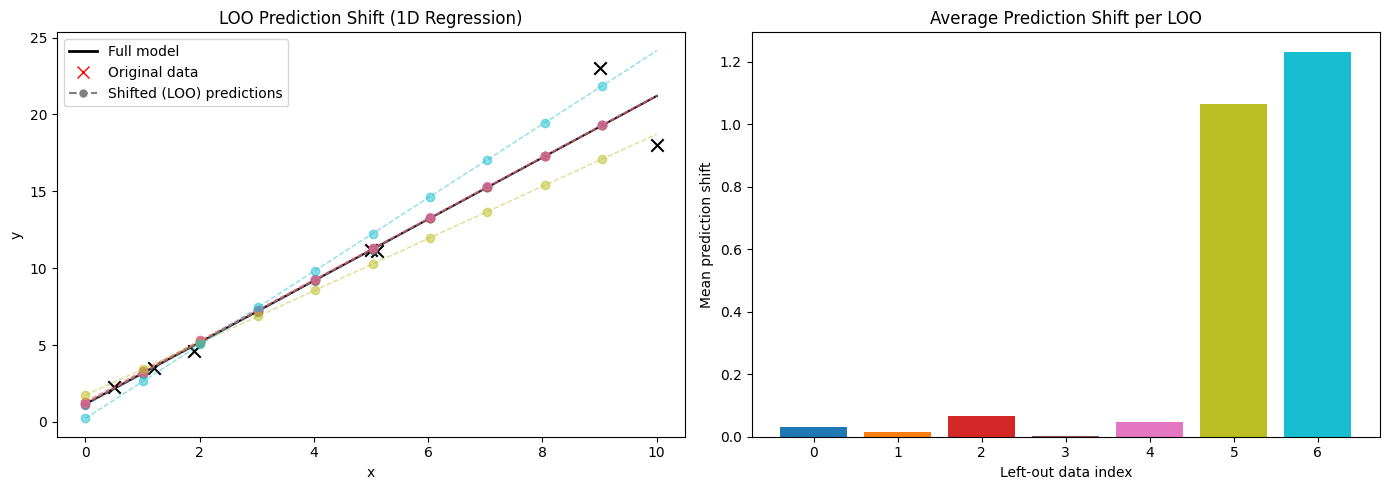

In [ ]:
#@title A simple demo of how each data point contributes to the final model {display-mode: "form"}
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from matplotlib import cm, colors
from matplotlib.lines import Line2D

# Generate unevenly spaced 1D data
np.random.seed(0)
x = np.array([0.5, 1.2, 1.9, 5.0, 5.1, 9.0, 10.0])
n = len(x)
y = 2 * x + 1 + np.array([0.3, 0.1, -0.2, 0.2, -0.1, 4.0, -3.0])  # induce shift
X = x.reshape(-1, 1)

# Fit full model
model_full = LinearRegression().fit(X, y)
x_range = np.linspace(0, 10, 200).reshape(-1, 1)
y_pred_full = model_full.predict(x_range)

# Leave-One-Out fits and shifts
y_preds_loo = []
shifts = []
for i in range(len(x)):
    mask = np.arange(len(x)) != i
    X_loo, y_loo = X[mask], y[mask]
    model_loo = LinearRegression().fit(X_loo, y_loo)
    y_pred_loo = model_loo.predict(x_range)
    y_preds_loo.append(y_pred_loo)
    shifts.append(np.mean(np.abs(y_pred_loo - y_pred_full)))  # average shift as influence

# Set up plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Colormap setup
n = len(x)
cmap = plt.colormaps.get_cmap('tab10')
norm = colors.Normalize(vmin=0, vmax=n - 1)
color_list = [cmap(norm(i)) for i in range(n)]

# Plot full model
ax1.plot(x_range, y_pred_full, color='black', label='Best-fit line using all points')

# Plot original data
ax1.scatter(x, y, color='black', marker='x', s=80, label='Original data point')

# Plot shifted predictions as dashed lines with dots
for i, y_pred_loo in enumerate(y_preds_loo):
    ax1.plot(x_range, y_pred_loo, linestyle='--', color=color_list[i], alpha=0.5, linewidth=1)
    ax1.plot(x_range[::20], y_pred_loo[::20], marker='o', linestyle='None', color=color_list[i], alpha=0.5)

# Add a single representative dashed line for legend
dummy_line, = ax1.plot([], [], linestyle='--', color='gray', label='Prediction shift when one point is left out')
dummy_dots = ax1.plot([], [], marker='o', linestyle='None', color='gray')[0]


# Custom legend handles
legend_elements = [
    Line2D([0], [0], color='black', lw=2, label='Best-fit line using all points'),
    Line2D([0], [0], marker='x', linestyle='None', markersize=8, label='Original data point'),
    Line2D([0], [0], color='gray', linestyle='--', marker='o', markersize=5, label='Prediction shift when one point is left out')
]

ax1.legend(handles=legend_elements, loc='upper left')
ax1.set_title("LOO Prediction Shift (1D Regression)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# Bar plot of influence magnitudes
ax2.bar(range(n), shifts, color=color_list)
ax2.set_title("Average Prediction Shift (Influence) per LOO")
ax2.set_xlabel("Left out Sample")
ax2.set_ylabel("Mean prediction shift")

plt.tight_layout()


**How each data point affects the prediction line.**

**Left:** The solid black line shows the best-fit line based on all points. Crosses are the original data. Each colored dash line with a dot shows how the prediction would shift if one point were left out.

**Right:** Bar plot showing how much each point changed the prediction when left out. Colors match the shifted lines on the left.



### Conclusion
This simple example shows how the presence or absence of just one data point can noticeably shift a model’s predictions. Even with a basic linear regression and only a handful of inputs, we can see how each training example leaves its fingerprint on the final result.

In more complex models — especially large language models trained on massive datasets — these individual influences are much harder to spot. But researchers have developed methods to trace and estimate them. If you're curious about how influence tracking works at scale and why it matters for questions like transparency, fairness, and copyright, you can continue with the optional reading: [“Making the Invisible Visible: Understanding Attribution and Data Influence in Generative AI”](https://github.com/WeihaoGe1009/ai-history-for-ip-scholars/blob/main/05_llms/optional_reading_01_training_data_influence.md)

## Take-home Messages

* Word frequency is a powerful baseline, but advanced models like SBERT can capture the meaning of a sentence by analyzing context, not just counting words.

* Modern large language models use the Transformer architecture to dynamically distribute attention across input tokens (like words in the sentences), allowing them to weigh different parts of the context as needed.

* It is technically possible to estimate how much influence each training example has on a model’s output. We demonstrated this with a simple regression model.

* (From Optional Reading) For large language models, influence tracing is feasible but approximate. The main ethical concerns lie in how “influence” is defined and used:

  * It often overlooks the collective impact of many contributors in favor of a few traceable sources.

  * It can reinforce visibility gaps, favoring dominant or repetitive data while marginalizing others.

  * It risks misuse in legal or ethical debates by reducing learning to a ranked list, ignoring questions of fairness and data justice.